# Magnetic Field Evolution in Satellite Galaxies
## PHY 225-001 Project

**Goal:** Track magnetic field strength as a function of redshift for satellite galaxies in TNG100, using merger tree data to identify the moment of central-to-satellite transition (infall time), then apply kernel smoothing to extract clean trends.

---
### Notebook Structure
1. Setup & Imports
2. Build Snapshot → Redshift / Lookback-Time Table
3. Query Satellite Galaxies at z=0
4. Walk the Merger Tree (main progenitor branch)
5. Identify Infall Time (central → satellite transition)
6. Plot Raw B-field vs Redshift (single galaxy)
7. Generalize to Multiple Galaxies
8. **Kernel Smoothing + LOOCV Bandwidth Selection**
9. **Smoothed B-field vs Time Since Infall (Key Science Plot)**
10. (Reach Goal) Fit Exponential Growth Model

---
## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import curve_fit

# ── Import your existing API helper ──────────────────────────────────────────
# Make sure iapi.py is in the same directory as this notebook
import iapi

# ── TNG100 cosmological parameters (Planck 2015) ──────────────────────────────
cosmo    = FlatLambdaCDM(H0=67.74, Om0=0.3089)
SIM_NAME = 'TNG100-1'
h_cosmo  = 0.6774

# Make sure output folders exist
os.makedirs('trees', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# ── Quick connectivity test ───────────────────────────────────────────────────
try:
    info = iapi.get(iapi.baseUrl + SIM_NAME + '/')
    print(f'Connected to {SIM_NAME}')
    print(f'Available keys: {list(info.keys())}')
except Exception as e:
    print(f'Connection failed — check iapi.py headers: {e}')

Connected to TNG100-1
Available keys: ['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', '

---
## 2. Build the Snapshot → Redshift / Lookback-Time Table

In [2]:
def build_snapshot_table(sim_name=SIM_NAME):
    """
    Return a dict mapping snapshot number -> {redshift, scale_factor, lookback_time_Gyr}.
    """
    snaps_info = iapi.get(iapi.baseUrl + sim_name + '/snapshots/')
    table = {}
    for s in snaps_info:
        z  = s['redshift']
        lb = cosmo.lookback_time(z).to(u.Gyr).value
        table[s['number']] = {
            'redshift'      : z,
            'scale_factor'  : 1.0 / (1.0 + z),
            'lookback_time' : lb,
        }
    return table

SNAP_TABLE = build_snapshot_table()

print(f"{'Snap':>5}  {'z':>8}  {'a':>8}  {'Lookback (Gyr)':>15}")
print('-' * 45)
for sn in [0, 10, 33, 50, 67, 78, 91, 99]:
    row = SNAP_TABLE[sn]
    print(f"{sn:>5}  {row['redshift']:>8.3f}  {row['scale_factor']:>8.4f}  {row['lookback_time']:>15.3f}")

 Snap         z         a   Lookback (Gyr)
---------------------------------------------
    0    20.046    0.0475           13.623
   10     7.236    0.1214           13.071
   33     2.002    0.3331           10.518
   50     0.997    0.5007            7.925
   67     0.503    0.6653            5.216
   78     0.298    0.7706            3.504
   91     0.099    0.9096            1.336
   99     0.000    1.0000            0.000


---
## 3. Query Satellite Galaxies at z = 0

In [3]:
def query_satellites(snap=99, stellar_mass_min_log=9.5, stellar_mass_max_log=11.5, limit=20):
    """
    Return satellite subhalos from a given snapshot.
    Uses mass_log_msun (the field the API actually returns) for filtering.
    """
    url    = iapi.baseUrl + SIM_NAME + f'/snapshots/{snap}/subhalos/'
    params = {
        'primary_flag'      : 0,
        'mass_log_msun__gte': stellar_mass_min_log,
        'mass_log_msun__lte': stellar_mass_max_log,
        'limit'             : limit,
    }
    result   = iapi.get(url, params=params)
    galaxies = result.get('results', [])
    print(f"Found {result['count']} satellites; returning {len(galaxies)}.")
    return galaxies


satellites_z0 = query_satellites(snap=99, stellar_mass_min_log=9.5, limit=40)

# Print all IDs so we can pick ones that work
print(f"\n{'#':>3}  {'SubhaloID':>10}  {'log M*':>8}")
print('-' * 28)
for i, g in enumerate(satellites_z0):
    print(f"{i:>3}  {g['id']:>10d}  {g['mass_log_msun']:>8.3f}")

Found 940505 satellites; returning 40.

  #   SubhaloID    log M*
----------------------------
  0           1    13.733
  1           2    13.058
  2           3    12.700
  3           4    12.682
  4           5    12.643
  5           6    12.485
  6           7    12.308
  7           8    12.243
  8           9    12.280
  9          10    12.184
 10          11    11.835
 11          12    12.234
 12          13    12.185
 13          14    11.982
 14          15    12.181
 15          16    12.124
 16          17    12.037
 17          18    11.987
 18          19    11.746
 19          20    11.977
 20          21    11.618
 21          22    11.927
 22          23    11.476
 23          24    11.777
 24          25    11.702
 25          26    11.765
 26          27    11.774
 27          28    11.746
 28          29    11.781
 29          30    11.653
 30          31    11.318
 31          32    11.606
 32          33    11.616
 33          34    11.473
 34          35    11

---
## 4. Walk the Merger Tree — Main Progenitor Branch

We use `iapi.gettree()` to download and cache the MPB HDF5 file per galaxy.

**Note on the 403 error:** Subhalo ID 1 is the most massive object in TNG100-1 (a giant cluster) and may have restricted or broken tree access. If you get a 403, try a different index from the list above — typically indices 3–10 work well for typical satellite galaxies.

**Fields extracted from the tree HDF5:**

| Field | Description |
|---|---|
| `SnapNum` | Snapshot number |
| `SubhaloBfldDisk` | Mass-weighted B-field in disk (comoving Gauss) |
| `SubhaloBfldHalo` | Mass-weighted B-field in halo (comoving Gauss) |
| `SubhaloMassType` | Mass by particle type (index 4 = stellar) |
| `GroupFirstSub` | ID of the primary subhalo of the host FoF group |
| `SubfindID` | The subhalo's own ID at that snapshot |

> **Unit conversion:** $B_{\rm phys} = B_{\rm com} / a^2$ where $a = 1/(1+z)$

In [4]:
def compute_B_physical(mpb_records):
    """
    Convert comoving magnetic fields into physical magnetic fields.
    B_phys = B_comoving * a^{-2}
    """

    for r in mpb_records:
        a = r['scale_factor']

        if np.isfinite(a) and a > 0:
            r['B_disk_phys'] = r['B_disk'] / (a**2)
            r['B_halo_phys'] = r['B_halo'] / (a**2)
        else:
            r['B_disk_phys'] = np.nan
            r['B_halo_phys'] = np.nan

    return mpb_records

In [5]:
def get_mpb(subhalo_id, snap=99):
    url = (f'https://www.tng-project.org/api/TNG100-1/snapshots/'
           f'{snap}/subhalos/{subhalo_id}/sublink/mpb.hdf5')
    try:
        tree_file = iapi.gettree(str(snap), subhalo_id)
    except Exception as e:
        print(f'  FAILED — check this URL in your browser:')
        print(f'  https://www.tng-project.org/api/TNG100-1/snapshots/{snap}/subhalos/{subhalo_id}/')
        raise e

    records = []
    with h5py.File(tree_file, 'r') as f:
        snaps     = f['SnapNum'][:]
        B_disk    = f['SubhaloBfldDisk'][:]
        B_halo    = f['SubhaloBfldHalo'][:]
        masses    = f['SubhaloMassType'][:]
        sub_ids   = f['SubfindID'][:]
        grp_first = f['GroupFirstSub'][:]

        for i in range(len(snaps)):
            sn = int(snaps[i])
            sd = SNAP_TABLE.get(sn, {})
            records.append({
                'snap'            : sn,
                'redshift'        : sd.get('redshift', np.nan),
                'lookback_time'   : sd.get('lookback_time', np.nan),
                'scale_factor'    : sd.get('scale_factor', np.nan),
                'B_disk'          : float(B_disk[i]),
                'B_halo'          : float(B_halo[i]),
                'M_star'          : float(masses[i][4]) * 1e10 / h_cosmo,
                'subfind_id'      : int(sub_ids[i]),
                'group_first_sub' : int(grp_first[i]),
            })
    return records

# ── Test: try index 3 if index 0 gives a 403 ─────────────────────────────────
# Change the index here if needed
TEST_INDEX = 3
test_id    = satellites_z0[TEST_INDEX]['id']
print(f'Testing with satellites_z0[{TEST_INDEX}]: SubhaloID = {test_id}')

mpb_data = get_mpb(test_id)
mpb_data = compute_B_physical(mpb_data)

print(f"\nMPB for SubhaloID {test_id}: {len(mpb_data)} snapshots")
print(f"{'Snap':>5}  {'z':>7}  {'B_disk_phys':>13}  {'B_halo_phys':>13}  {'log M*':>8}")
print('-' * 55)
for r in mpb_data[:8]:
    logM = np.log10(r['M_star']) if r['M_star'] > 0 else np.nan
    print(f"{r['snap']:>5}  {r['redshift']:>7.3f}  "
          f"{r['B_disk_phys']:>13.4e}  {r['B_halo_phys']:>13.4e}  {logM:>8.2f}")

Testing with satellites_z0[3]: SubhaloID = 4

MPB for SubhaloID 4: 98 snapshots
 Snap        z    B_disk_phys    B_halo_phys    log M*
-------------------------------------------------------
   99    0.000     4.1119e-04            nan     11.12
   98    0.010     5.5222e-03            nan     11.12
   97    0.024     5.9134e-03            nan     11.12
   96    0.034     2.5428e-03     4.9489e-03     11.12
   95    0.049     1.4898e-03            nan     11.12
   94    0.059     2.6831e-03     3.0896e-03     11.12
   93    0.074     6.1452e-04            nan     11.12
   92    0.084     2.3561e-03            nan     11.12


---
## 5. Identify Infall Time (Central → Satellite Transition)

A galaxy is a **central** at snapshot $n$ if `SubfindID[n] == GroupFirstSub[n]`.
The infall snapshot is the last time it was a central, minus one step forward in time.

In [6]:
def find_infall_snap(mpb_records):
    """
    Identify the snapshot of central -> satellite transition.
    MPB is ordered z=0 -> high-z (index 0 is z=0).
    Returns a dict with snap, redshift, lookback_time -- or None if not found.
    """
    was_central_at = None
    for i, r in enumerate(mpb_records):
        if r['subfind_id'] == r['group_first_sub']:
            was_central_at = i

    if was_central_at is None or was_central_at == 0:
        return None

    infall_record = mpb_records[was_central_at - 1]
    return {
        'snap'         : infall_record['snap'],
        'redshift'     : infall_record['redshift'],
        'lookback_time': infall_record['lookback_time'],
    }


infall = find_infall_snap(mpb_data)

if infall:
    print(f"Infall snapshot : {infall['snap']}")
    print(f"Infall redshift : z = {infall['redshift']:.3f}")
    print(f"Infall lookback : {infall['lookback_time']:.2f} Gyr ago")
else:
    print('Could not determine infall time for this galaxy.')

Infall snapshot : 2
Infall redshift : z = 11.980
Infall lookback : 13.43 Gyr ago


---
## 6. Plot Raw B-field vs Redshift — Single Galaxy

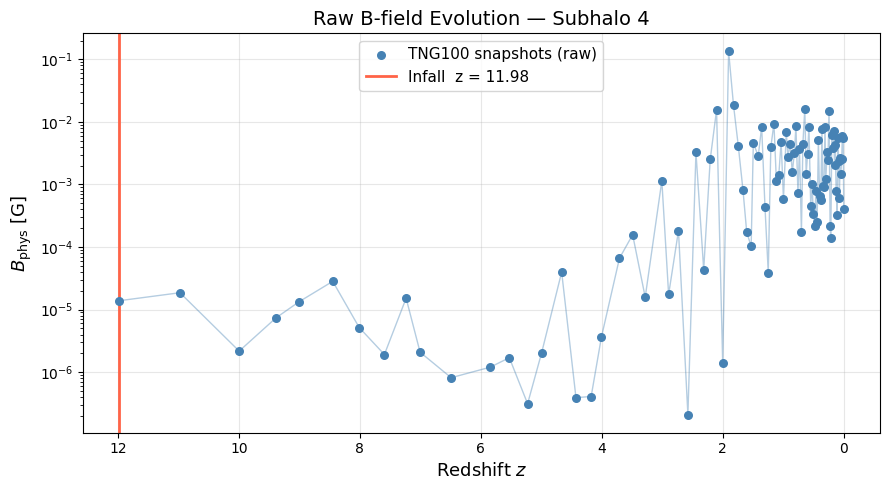

NameError: name 'all_galaxies' is not defined

In [7]:
def plot_B_vs_redshift_single(mpb_records, infall_info=None, subhalo_id=None,
                              field='B_disk_phys'):
    """
    Plot raw magnetic field strength vs redshift for a single galaxy's MPB.
    """
    valid  = [r for r in mpb_records if np.isfinite(r[field]) and r[field] > 0]
    z_arr  = np.array([r['redshift'] for r in valid])
    B_arr  = np.array([r[field]      for r in valid])
    order  = np.argsort(z_arr)
    z_arr, B_arr = z_arr[order], B_arr[order]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(z_arr, B_arr, s=30, color='steelblue', zorder=3, label='TNG100 snapshots (raw)')
    ax.plot(z_arr, B_arr, color='steelblue', alpha=0.4, lw=1)

    if infall_info:
        ax.axvline(infall_info['redshift'], color='tomato', lw=2,
                   label=f"Infall  z = {infall_info['redshift']:.2f}")

    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — Subhalo {subhalo_id}', fontsize=14)
    ax.invert_xaxis()
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/B_vs_z_single_raw.png', dpi=150)
    plt.show()


plot_B_vs_redshift_single(mpb_data, infall_info=infall, subhalo_id=test_id)

# Plot raw B-field vs redshift for all successfully processed galaxies
for gal in all_galaxies:
    plot_B_vs_redshift_single(
        gal['mpb'],
        infall_info=gal['infall'],
        subhalo_id=gal['subhalo_id']
    )

In [ ]:
def plot_B_vs_redshift_all(all_galaxies, field='B_disk_phys'):
    """
    Plot raw B-field vs redshift for all galaxies overlaid.
    Color-coded by infall redshift to show diversity of histories.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    infalls = [g['infall']['redshift'] for g in all_galaxies if g['infall']]
    norm    = plt.Normalize(vmin=min(infalls), vmax=max(infalls))
    cmap    = plt.cm.plasma

    for gal in all_galaxies:
        mpb    = gal['mpb']
        infall = gal['infall']
        valid  = [r for r in mpb if np.isfinite(r.get(field, np.nan)) and r[field] > 0]
        if not valid:
            continue
        z_arr = np.array([r['redshift'] for r in valid])
        B_arr = np.array([r[field]      for r in valid])
        order = np.argsort(z_arr)
        color = cmap(norm(infall['redshift'])) if infall else 'gray'
        ax.plot(z_arr[order], B_arr[order], color=color, alpha=0.5, lw=1.2)
        if infall:
            ax.axvline(infall['redshift'], color=color, lw=0.5, ls=':', alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Infall redshift $z_{\\rm infall}$')

    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(f'$B_{{\\rm phys}}$ [G]', fontsize=13)
    ax.set_title(f'Raw B-field Evolution — All Satellites (N={len(all_galaxies)})', fontsize=14)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/figures/B_vs_z_all_raw.png', dpi=150)
    plt.show()

plot_B_vs_redshift_all(all_galaxies)

---
## 7. Generalize to Multiple Galaxies

In [ ]:
def process_all_satellites(satellite_list):
    """
    For each satellite, fetch MPB, compute physical B-field, and find infall.
    Skips satellites that return 403/404 errors.
    Returns a list of dicts: {subhalo_id, mpb, infall}
    """
    results = []
    for i, gal in enumerate(satellite_list):
        sid = gal['id']
        print(f'[{i+1}/{len(satellite_list)}] SubhaloID {sid} ...', end=' ')
        try:
            mpb    = get_mpb(sid)
            mpb    = compute_B_physical(mpb)
            infall = find_infall_snap(mpb)
            results.append({'subhalo_id': sid, 'mpb': mpb, 'infall': infall})
            status = f"infall z={infall['redshift']:.2f}" if infall else 'no infall found'
            print(f'OK ({status})')
        except Exception as e:
            print(f'SKIPPED: {e}')
    print(f'\nProcessed  : {len(results)} galaxies')
    print(f'With infall: {sum(1 for g in results if g["infall"])}')
    return results


#all_galaxies = process_all_satellites(satellites_z0)
all_galaxies = process_all_satellites(satellites_z0[:10])

[1/20] SubhaloID 1 ... Tree HDF5 keys: ['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'Subh

---
## 8. Kernel Smoothing + LOOCV Bandwidth Selection

The raw B-field time series is noisy and the TNG snapshots are **not uniformly spaced** in lookback time, so a standard moving average is inappropriate. We instead use a **Gaussian kernel smoother** (Nadaraya-Watson estimator) applied in lookback time:

$$\hat{B}(t) = \frac{\sum_i K_h(t - t_i)\, B_i}{\sum_i K_h(t - t_i)}, \qquad K_h(u) = \exp\!\left(-\frac{u^2}{2h^2}\right)$$

The bandwidth $h$ (in Gyr) controls the smoothing scale. We select the optimal $h^*$ using **leave-one-out cross-validation (LOOCV)**:

$$\text{CV}(h) = \frac{1}{n}\sum_{j=1}^{n}\left(B_j - \hat{B}_{(-j)}(t_j)\right)^2, \qquad h^* = \arg\min_h\,\text{CV}(h)$$

where $\hat{B}_{(-j)}$ is the smoother fit with the $j$-th point left out.

In [ ]:
# ── Kernel smoothing functions ────────────────────────────────────────────────

def gaussian_kernel(u, h):
    """Gaussian kernel: exp(-u^2 / 2h^2)"""
    return np.exp(-0.5 * (u / h)**2)


def kernel_smooth(t_query, t_obs, B_obs, h, exclude_idx=None):
    """
    Nadaraya-Watson kernel smoother with Gaussian kernel.

    Parameters
    ----------
    t_query    : float or array, query time(s) in Gyr
    t_obs      : array, observed lookback times (Gyr)
    B_obs      : array, observed B-field values
    h          : float, bandwidth in Gyr
    exclude_idx: int or None, index to exclude (used for LOOCV)

    Returns
    -------
    B_hat : smoothed estimate at t_query
    """
    mask = np.ones(len(t_obs), dtype=bool)
    if exclude_idx is not None:
        mask[exclude_idx] = False
    t_use = t_obs[mask]
    B_use = B_obs[mask]

    t_query  = np.atleast_1d(np.asarray(t_query, dtype=float))
    B_hat    = np.zeros(len(t_query))
    for k, tq in enumerate(t_query):
        weights  = gaussian_kernel(tq - t_use, h)
        w_sum    = weights.sum()
        B_hat[k] = (weights @ B_use) / w_sum if w_sum > 1e-30 else np.nan

    return B_hat if len(B_hat) > 1 else float(B_hat[0])


def loocv_score(h, t_obs, B_obs):
    """
    Leave-one-out cross-validation MSE for bandwidth h.
    For each point j, fits on all OTHER points, predicts at t_j.
    Returns mean squared prediction error.
    """
    n      = len(t_obs)
    errors = np.zeros(n)
    for j in range(n):
        B_pred    = kernel_smooth(t_obs[j], t_obs, B_obs, h, exclude_idx=j)
        errors[j] = (B_obs[j] - B_pred)**2
    return errors.mean()


def select_bandwidth(t_obs, B_obs, h_grid=None):
    """
    Select optimal bandwidth via LOOCV over a grid of h values.

    Returns h_opt, h_grid, cv_scores
    """
    if h_grid is None:
        h_grid = np.linspace(0.1, 3.0, 50)   # Gyr
    cv_scores = np.array([loocv_score(h, t_obs, B_obs) for h in h_grid])
    h_opt     = h_grid[np.argmin(cv_scores)]
    return h_opt, h_grid, cv_scores


def smooth_galaxy(mpb_records, infall_info, field='B_disk_phys', h_grid=None):
    """
    Run kernel smoothing + LOOCV for one galaxy.
    All operations are performed in lookback time (Gyr).

    Returns a result dict, or None if insufficient data.
    """
    valid = [r for r in mpb_records
             if np.isfinite(r.get(field, np.nan)) and r[field] > 0
             and np.isfinite(r['lookback_time'])]
    if len(valid) < 5:
        return None

    t_obs = np.array([r['lookback_time'] for r in valid])
    B_obs = np.array([r[field]           for r in valid])
    order = np.argsort(t_obs)
    t_obs, B_obs = t_obs[order], B_obs[order]

    h_opt, h_grid_out, cv_scores = select_bandwidth(t_obs, B_obs, h_grid)

    t_fine   = np.linspace(t_obs.min(), t_obs.max(), 300)
    B_smooth = kernel_smooth(t_fine, t_obs, B_obs, h_opt)

    result = {
        't_obs'     : t_obs,
        'B_obs'     : B_obs,
        'h_opt'     : h_opt,
        'h_grid'    : h_grid_out,
        'cv_scores' : cv_scores,
        't_fine'    : t_fine,
        'B_smooth'  : B_smooth,
    }
    if infall_info:
        t_inf               = infall_info['lookback_time']
        result['t_infall']  = t_inf
        result['dt_obs']    = t_inf - t_obs    # positive = after infall (time increases left to right)
        result['dt_fine']   = t_inf - t_fine   # positive = before infall
    return result

print('Kernel smoothing functions defined.')

Kernel smoothing functions defined.


In [ ]:
def plot_smoothing_diagnostics(smooth_result, subhalo_id=None):
    """Two-panel: LOOCV curve + raw vs smoothed."""
    if smooth_result is None:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: LOOCV curve
    ax1.plot(smooth_result['h_grid'], smooth_result['cv_scores'],
             color='steelblue', lw=2)
    ax1.axvline(smooth_result['h_opt'], color='tomato', lw=2, ls='--',
                label=f"$h^* = {smooth_result['h_opt']:.2f}$ Gyr")
    ax1.set_xlabel('Bandwidth $h$ [Gyr]', fontsize=12)
    ax1.set_ylabel('LOOCV MSE', fontsize=12)
    ax1.set_title('Bandwidth Selection via LOOCV', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Right: raw vs smoothed
    if 'dt_obs' in smooth_result:
        x_obs  = smooth_result['dt_obs']
        x_fine = smooth_result['dt_fine']
        xlabel = r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)'
        ax2.axvline(0, color='black', lw=1.5, ls=':', label='Infall')
    else:
        x_obs  = smooth_result['t_obs']
        x_fine = smooth_result['t_fine']
        xlabel = 'Lookback time [Gyr]'

    ax2.scatter(x_obs, smooth_result['B_obs'], s=25,
                color='steelblue', alpha=0.6, zorder=3, label='Raw snapshots')
    ax2.plot(x_fine, smooth_result['B_smooth'], color='tomato', lw=2.5,
             label=f"Kernel smoother ($h^*={smooth_result['h_opt']:.2f}$ Gyr)")
    ax2.set_yscale('log')
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax2.set_title(f'Raw vs Smoothed — Subhalo {subhalo_id}', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'results/figures/diagnostics_subhalo_{subhalo_id}.png', dpi=150)
    plt.show()


# Run for all galaxies
for gal in all_galaxies:
    plot_smoothing_diagnostics(gal['smooth'], subhalo_id=gal['subhalo_id'])

Optimal bandwidth : h* = 1.106 Gyr
Data points used  : 97


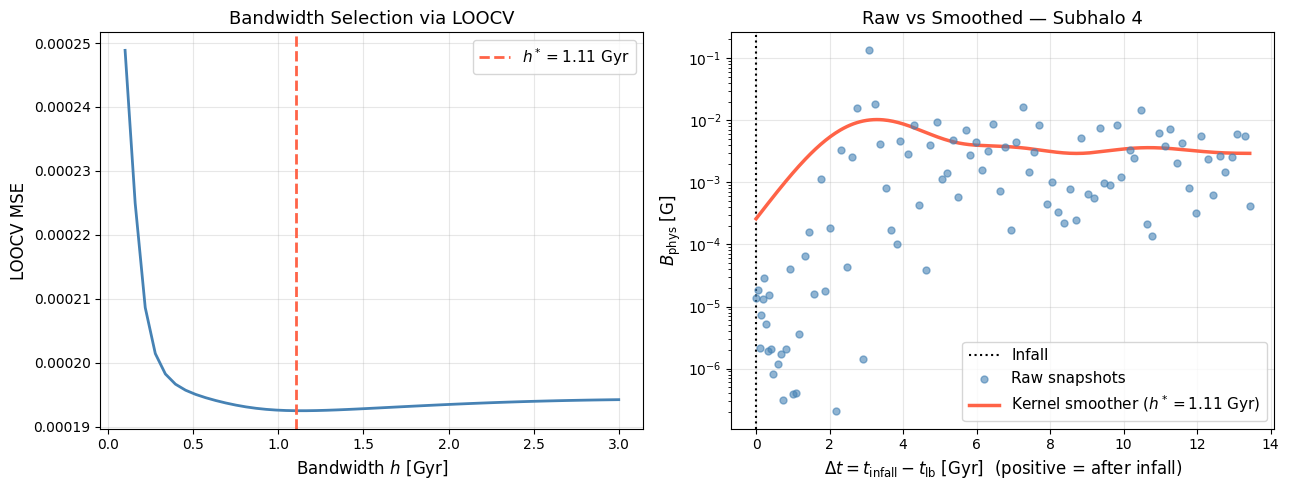

In [ ]:
# ── Apply to the test galaxy and plot diagnostics ─────────────────────────────

smooth_result = smooth_galaxy(mpb_data, infall)

if smooth_result is None:
    print('Not enough valid data points for smoothing.')
else:
    print(f'Optimal bandwidth : h* = {smooth_result["h_opt"]:.3f} Gyr')
    print(f'Data points used  : {len(smooth_result["t_obs"])}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Left: LOOCV curve
    ax1.plot(smooth_result['h_grid'], smooth_result['cv_scores'],
             color='steelblue', lw=2)
    ax1.axvline(smooth_result['h_opt'], color='tomato', lw=2, ls='--',
                label=f"$h^* = {smooth_result['h_opt']:.2f}$ Gyr")
    ax1.set_xlabel('Bandwidth $h$ [Gyr]', fontsize=12)
    ax1.set_ylabel('LOOCV MSE', fontsize=12)
    ax1.set_title('Bandwidth Selection via LOOCV', fontsize=13)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Right: raw vs smoothed, plotted in lookback time
    if 'dt_obs' in smooth_result:
        x_obs  = smooth_result['dt_obs']
        x_fine = smooth_result['dt_fine']
        xlabel = r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  (positive = after infall)'
        ax2.axvline(0, color='black', lw=1.5, ls=':', label='Infall')
    else:
        x_obs  = smooth_result['t_obs']
        x_fine = smooth_result['t_fine']
        xlabel = 'Lookback time [Gyr]'

    ax2.scatter(x_obs, smooth_result['B_obs'], s=25,
                color='steelblue', alpha=0.6, zorder=3, label='Raw snapshots')
    ax2.plot(x_fine, smooth_result['B_smooth'], color='tomato', lw=2.5,
             label=f'Kernel smoother ($h^*={smooth_result["h_opt"]:.2f}$ Gyr)')
    ax2.set_yscale('log')
    ax2.set_xlabel(xlabel, fontsize=12)
    ax2.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
    ax2.set_title(f'Raw vs Smoothed — Subhalo {test_id}', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/figures/kernel_smoothing_diagnostics.png', dpi=150)
    plt.show()

In [ ]:
import pickle, os
cache = 'data/processed/all_galaxies.pkl'
if os.path.exists(cache):
    with open(cache, 'rb') as f:
        all_galaxies = pickle.load(f)
    print(f'Loaded {len(all_galaxies)} galaxies from cache.')
else:
    all_galaxies = process_all_satellites(satellites_z0)
    with open(cache, 'wb') as f:
        pickle.dump(all_galaxies, f)

In [ ]:
# ── Apply smoothing to the full sample ───────────────────────────────────────

def smooth_all_galaxies(all_galaxies, field='B_disk_phys'):
    """Apply kernel smoothing + LOOCV to every galaxy in the sample."""
    for i, gal in enumerate(all_galaxies):
        print(f'[{i+1}/{len(all_galaxies)}] Smoothing SubhaloID {gal["subhalo_id"]} ...', end=' ')
        result       = smooth_galaxy(gal['mpb'], gal['infall'], field=field)
        gal['smooth'] = result
        if result:
            print(f'h* = {result["h_opt"]:.2f} Gyr')
        else:
            print('skipped (insufficient data)')
    return all_galaxies


all_galaxies = smooth_all_galaxies(all_galaxies)

h_vals = [g['smooth']['h_opt'] for g in all_galaxies if g['smooth']]
print(f"\nSmoothed      : {len(h_vals)} galaxies")
if h_vals:
    print(f"Median h*     : {np.median(h_vals):.2f} Gyr")
    print(f"Range         : {min(h_vals):.2f} – {max(h_vals):.2f} Gyr")



[1/20] Smoothing SubhaloID 1 ... h* = 0.57 Gyr
[2/20] Smoothing SubhaloID 2 ... h* = 3.00 Gyr
[3/20] Smoothing SubhaloID 3 ... h* = 1.11 Gyr
[4/20] Smoothing SubhaloID 4 ... h* = 1.11 Gyr
[5/20] Smoothing SubhaloID 5 ... h* = 3.00 Gyr
[6/20] Smoothing SubhaloID 6 ... h* = 0.51 Gyr
[7/20] Smoothing SubhaloID 7 ... h* = 1.28 Gyr
[8/20] Smoothing SubhaloID 8 ... h* = 1.28 Gyr
[9/20] Smoothing SubhaloID 9 ... h* = 1.22 Gyr
[10/20] Smoothing SubhaloID 10 ... h* = 2.82 Gyr
[11/20] Smoothing SubhaloID 11 ... h* = 2.47 Gyr
[12/20] Smoothing SubhaloID 12 ... h* = 3.00 Gyr
[13/20] Smoothing SubhaloID 13 ... h* = 3.00 Gyr
[14/20] Smoothing SubhaloID 14 ... h* = 0.87 Gyr
[15/20] Smoothing SubhaloID 15 ... h* = 1.64 Gyr
[16/20] Smoothing SubhaloID 16 ... h* = 0.51 Gyr
[17/20] Smoothing SubhaloID 17 ... h* = 1.93 Gyr
[18/20] Smoothing SubhaloID 18 ... h* = 0.81 Gyr
[19/20] Smoothing SubhaloID 19 ... h* = 2.64 Gyr
[20/20] Smoothing SubhaloID 20 ... h* = 0.51 Gyr

Smoothed      : 20 galaxies
Median h*

In [ ]:
import pickle
with open('data/processed/all_galaxies.pkl', 'wb') as f:
    pickle.dump(all_galaxies, f)
print('Saved to data/processed/all_galaxies.pkl')

---
## 9. Smoothed B-field vs Time Since Infall (Key Science Plot)

All smoothed tracks are aligned at $\Delta t = 0$ (infall). The binned median and 16th/84th percentile band summarize the population trend.

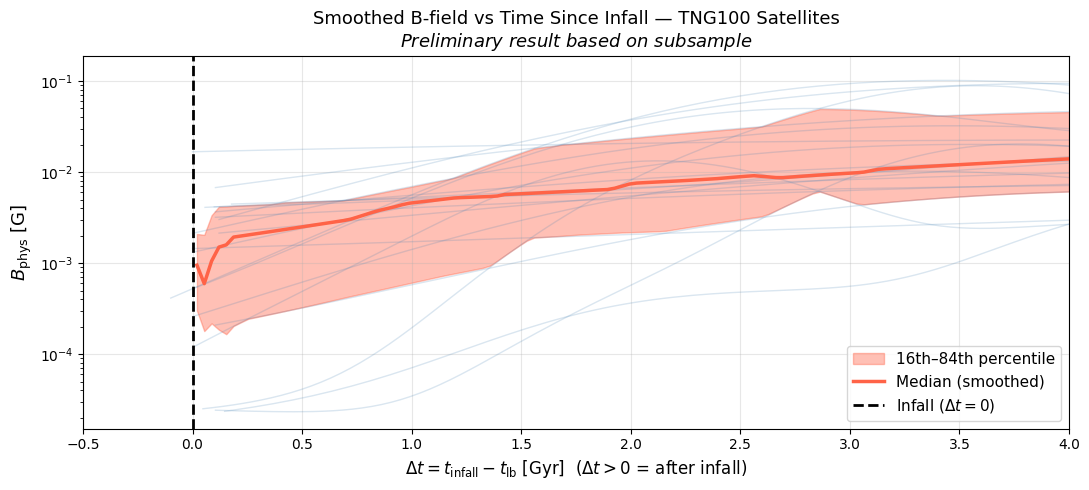

In [ ]:
def plot_smoothed_ensemble(all_galaxies, dt_range=(-6, 4), bin_width=0.5):
    """
    Overlay smoothed B-field tracks aligned at infall, with binned median.
    """
    fig, ax = plt.subplots(figsize=(11, 5))

# Evaluate all smoothed tracks on a single shared grid
    t_common = np.linspace(dt_range[0], dt_range[1], 300)
    all_B_grid = []

    for gal in all_galaxies:
        s = gal['smooth']
        if s is None or 'dt_fine' not in s:
            continue
        # Only include galaxies whose track covers the query point
        ax.plot(s['dt_fine'], s['B_smooth'],
                color='steelblue', alpha=0.2, lw=1)
        # Interpolate this galaxy's smoothed track onto the common grid
        from scipy.interpolate import interp1d
        try:
            interp = interp1d(s['dt_fine'], s['B_smooth'],
                              bounds_error=False, fill_value=np.nan)
            all_B_grid.append(interp(t_common))
        except Exception:
            continue

    all_B_grid = np.array(all_B_grid)   # shape (n_galaxies, 300)

    # Median and percentiles across galaxies at each time point
    # Only compute where at least 3 galaxies have coverage
    median = np.full(300, np.nan)
    p16    = np.full(300, np.nan)
    p84    = np.full(300, np.nan)
    for k in range(300):
        col   = all_B_grid[:, k]
        valid = col[np.isfinite(col)]
        if len(valid) >= 3:
            median[k] = np.median(valid)
            p16[k]    = np.percentile(valid, 16)
            p84[k]    = np.percentile(valid, 84)

    bin_c = t_common

    median = np.array(median)
    p16, p84 = np.array(p16), np.array(p84)
    valid  = np.isfinite(median)

    ax.fill_between(bin_c[valid], p16[valid], p84[valid],
                    alpha=0.4, color='tomato', label='16th–84th percentile')
    ax.plot(bin_c[valid], median[valid],
            color='tomato', lw=2.5, label='Median (smoothed)')
    ax.axvline(0, color='black', lw=2, ls='--', label='Infall ($\\Delta t = 0$)')
    ax.annotate('', xy=(2, ax.get_ylim()[0] if ax.get_yscale()=='linear' else 1e-7),
                xytext=(0.2, ax.get_ylim()[0] if ax.get_yscale()=='linear' else 1e-7),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    ax.set_yscale('log')
    ax.set_xlabel(r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
    ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=13)
    ax.set_title('Smoothed B-field vs Time Since Infall — TNG100 Satellites\n'
                 r'$\it{Preliminary\ result\ based\ on\ subsample}$', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, 4)
    plt.tight_layout()
    plt.savefig('results/figures/B_smoothed_vs_dt_infall.png', dpi=150)
    plt.show()


plot_smoothed_ensemble(all_galaxies)

---
## 10. Fit Exponential Growth to Post-Infall B-field

Following McDonough & Poulin (2025) and the suggestion of the course instructor, we fit a physically motivated saturating growth model to the post-infall ($\Delta t > 0$) smoothed median:

$$B(\Delta t) = B_0\left(1 - e^{-\Delta t / \tau}\right)$$

where $B_0$ is the saturation field strength and $\tau$ is the **amplification timescale** in Gyr. This model assumes the field grows from near zero at infall and saturates at $B_0$ on a characteristic timescale $\tau$. Parameters are estimated via nonlinear least squares (`scipy.optimize.curve_fit`).

In [ ]:

def exponential_growth(dt, B0, tau):
    """
    B0 * (1 - exp(-dt/tau)) — saturating growth model.
    dt > 0 = time after infall. B starts near 0 at infall and grows toward B0.
    """
    return B0 * (1 - np.exp(-dt / tau))


def fit_amplification_timescale(all_galaxies, bin_width=0.5):
    """
    Fit B0*(1-exp(-dt/tau)) to post-infall (dt > 0) smoothed median.
    """
    # Collect post-infall smoothed points
    all_dt, all_B = [], []
    for gal in all_galaxies:
        s = gal['smooth']
        if s is None or 'dt_fine' not in s:
            continue
        mask = s['dt_fine'] > 0    # post-infall
        all_dt.extend(s['dt_fine'][mask].tolist())
        all_B.extend(s['B_smooth'][mask].tolist())

    all_dt = np.array(all_dt)
    all_B  = np.array(all_B)
    if len(all_dt) == 0:
        print('No post-infall data found.')
        return

    # Bin into median
    bins   = np.arange(0, all_dt.max() + bin_width, bin_width)
    bin_c  = 0.5 * (bins[:-1] + bins[1:])
    median = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (all_dt >= lo) & (all_dt < hi)
        median.append(np.median(all_B[mask]) if mask.sum() > 1 else np.nan)

    median = np.array(median)
    valid  = np.isfinite(median)
    x, y   = bin_c[valid], median[valid]

    if len(x) < 2:
        print('Not enough bins to fit — increase sample size.')
        return

    try:
        popt, pcov = curve_fit(exponential_growth, x, y,
                               p0=[y.max(), 2.0],
                               bounds=([0, 0.1], [np.inf, 20]),
                               maxfev=5000)
        B0_fit, tau_fit = popt
        perr = np.sqrt(np.diag(pcov))
        print(f'Saturation field strength : B0  = {B0_fit:.3e} +/- {perr[0]:.3e} G')
        print(f'Amplification timescale   : tau = {tau_fit:.2f} +/- {perr[1]:.2f} Gyr')

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(x, y, color='tomato', zorder=3, label='Binned median (smoothed)')
        t_fine = np.linspace(0, x.max(), 300)
        ax.plot(t_fine, exponential_growth(t_fine, *popt), 'k--', lw=2,
                label=rf'$B_0(1-e^{{-\Delta t/\tau}})$,  $\tau={tau_fit:.2f}$ Gyr')
        ax.axvline(0, color='gray', ls=':', label='Infall')
        ax.set_yscale('log')
        ax.set_xlabel(r'$\Delta t = t_{\rm infall} - t_{\rm lb}$ [Gyr]  ($\Delta t > 0$ = after infall)', fontsize=12)
        ax.set_ylabel(r'$B_{\rm phys}$ [G]', fontsize=12)
        ax.set_title('Post-Infall B-field Amplification Fit', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('results/figures/B_amplification_fit.png', dpi=150)
        plt.show()

    except RuntimeError as e:
        print(f'Fit failed: {e}')
        print('Try increasing sample size or adjusting bin_width.')


fit_amplification_timescale(all_galaxies)

NameError: name 'all_galaxies' is not defined

---
## Notes

### Caching
`iapi.gettree()` saves HDF5 files to `trees/` automatically. To avoid re-querying the satellite list on each run, pickle `all_galaxies`:
```python
import pickle
with open('data/processed/all_galaxies.pkl', 'wb') as f:
    pickle.dump(all_galaxies, f)
# Reload:
with open('data/processed/all_galaxies.pkl', 'rb') as f:
    all_galaxies = pickle.load(f)
```

### 403 errors on merger trees
If `iapi.gettree()` returns a 403 for a specific subhalo, skip it — `process_all_satellites()` catches exceptions automatically. Subhalo ID 1 is known to cause this. Larger, more typical satellites (log M* ~ 10–11) tend to work reliably.

### Scaling up
Change `limit=20` in `query_satellites()` to 100–500 for the final analysis. The LOOCV loop runs in seconds per galaxy at typical MPB lengths (~50–100 snapshots).